# Compare saved detector runs
Change `RUNS`, `SELECTION_MODE`, and `POLICY` in the next cell. For real comparisons, point each alias at a different run's `threshold_comparison` directory. Summary sections load exported scores; the example-inspection sections replay saved checkpoints on current validation and training data at their exported operating points. It does not retrain, resweep thresholds, or retune a model.

Selections and exported scores below come from the same validation recordings (`tuned_validation`), so these are descriptive comparisons, not independent test-set estimates. Training replay is an in-sample label audit. The loader rejects incompatible data, preprocessing, threshold grids, matching rules, or selection constraints.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Open from repository root or main_notebooks/'

RUNS = {
    'Baseline': 'testing_checkpoints/(4)baseline/threshold_comparison',
    '(labels delayed 8 frames)': 'testing_checkpoints/(4)delay8/threshold_comparison',
    '(LSTM64 delay 8)': 'testing_checkpoints/(4)lstm64d8/threshold_comparison',
    '(LSTM64-64 delay8)': 'testing_checkpoints/(4)lstm64-64d8/threshold_comparison',
    'original': 'testing_checkpoints/baseline_no_changes/threshold_comparison'
}
SELECTION_MODE = 'max_f1'
POLICY = 'lookahead_12f'
assert len(RUNS) >= 2, 'Provide at least two uniquely named runs.'

def read_export(directory, name):
    path = directory / f'{name}.csv'
    if not path.is_file():
        raise FileNotFoundError(f'{path}: rerun the export cell in baseline_evaluation.ipynb')
    return pd.read_csv(path)

sources, selections, summaries, type_tables, file_tables = [], [], [], [], []
for label, folder in RUNS.items():
    directory = ROOT / folder
    selected = read_export(directory, 'selected_thresholds')
    chosen = selected[(selected.selection_mode == SELECTION_MODE) & (selected.policy == POLICY)]
    if len(chosen) != 1:
        raise ValueError(f'{label}: expected exactly one selection for {SELECTION_MODE}/{POLICY}')
    choice = chosen.iloc[0]
    if not bool(choice.feasible):
        raise ValueError(f'{label}: requested selection is infeasible: {choice.infeasible_reason}')
    tables = [read_export(directory, name) for name in
              ('comparison_summary', 'type_metrics_all_modes', 'recording_metrics_all_modes')]
    matching = [table[(table.selection_mode == SELECTION_MODE) & (table.policy == POLICY)].copy()
                for table in tables]
    for table in matching:
        assert len(table), f'{label}: selected mode/policy missing in an exported table'
        assert np.allclose(table.left_threshold, choice.left_threshold)
        assert np.allclose(table.right_threshold, choice.right_threshold)
        assert table.checkpoint_sha256.nunique() == 1
        assert table.checkpoint_sha256.iloc[0] == choice.checkpoint_sha256
        table['model'] = label
    summary, by_type, by_file = matching
    assert set(summary.level) == {'window', 'frame', 'event'}
    assert set(summary.side) == {'all', 'left', 'right'}
    assert len(summary) == 9
    for kind in ('window', 'event'):
        overall = summary[(summary.level == kind) & (summary.side == 'all')].iloc[0]
        for count in ('tp', 'fp', 'fn'):
            assert by_file[f'{kind}_{count}'].sum() == by_type[f'{kind}_{count}'].sum() == overall[count]
    sources.append(dict(model=label, folder=str(directory), model_id=choice.model_id,
                        checkpoint_sha256=choice.checkpoint_sha256,
                        validation_sha256=choice.validation_sha256,
                        preprocessing_sha256=choice.preprocessing_sha256,
                        evaluation_design=choice.evaluation_design))
    selections.append(choice.to_dict() | {'model': label})
    summaries.append(summary)
    type_tables.append(by_type)
    file_tables.append(by_file)
comparison_sources = pd.DataFrame(sources)
operating_points = pd.DataFrame(selections)
scores = pd.concat(summaries, ignore_index=True)
type_scores = pd.concat(type_tables, ignore_index=True)
file_scores = pd.concat(file_tables, ignore_index=True)
must_agree = ['validation_sha256', 'preprocessing_sha256', 'selection_split',
              'evaluation_split', 'evaluation_design', 'threshold_grid', 'recall_target',
              'fp_per_min_limit', 'timely_budget_frames', 'early_allowance_frames',
              'max_late_frames', 'refractory_sec', 'frame_label_half_width']
for field in must_agree:
    assert scores[field].nunique(dropna=False) == 1, f'Runs differ in {field}; comparison is not like-for-like'
first_label = next(iter(RUNS))
expected_files = set(file_scores[file_scores.model == first_label].file)
expected_types = set(type_scores[type_scores.model == first_label].recording_type)
for label in RUNS:
    assert set(file_scores[file_scores.model == label].file) == expected_files, 'Recordings differ'
    assert set(type_scores[type_scores.model == label].recording_type) == expected_types, 'Types differ'
if comparison_sources.checkpoint_sha256.nunique() < len(RUNS):
    print('Demo: some aliases use identical weights. Replace RUNS paths to compare different models.')
comparison_sources

,model,folder,model_id,checkpoint_sha256,validation_sha256,preprocessing_sha256,evaluation_design
0,Baseline,/home/aprohack/desktop/work/tap-project/projec...,(3)baseline,a56582a87459bb72ca97f22364d89ca951517b96bb06be...,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
1,(labels delayed 8 frames),/home/aprohack/desktop/work/tap-project/projec...,(3)delay8,64eb3e600b76d1673ff5003a3b2c9b5229c998ed1150c8...,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
2,(LSTM64),/home/aprohack/desktop/work/tap-project/projec...,(3)lstm64,816ec4a2fce847e073c181def4c74b1ba056773148b8bc...,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
3,(LSTM64 no augment),/home/aprohack/desktop/work/tap-project/projec...,(3)lstm64,34d60e0e0bcee7508355d71d8b6824da729765c27583fd...,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
4,(LSTM64-64),/home/aprohack/desktop/work/tap-project/projec...,(3)lstm64-64,4cc597d79c27eed3302b0dd6b7d8ef54ca2237ba41b99b...,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
5,(LSTM64-64 no augment),/home/aprohack/desktop/work/tap-project/projec...,(3)lstm64-64,328b03580eafab12885a32c4dead6ed60e982580e48841...,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
6,original,/home/aprohack/desktop/work/tap-project/projec...,baseline_no_changes,49f96114aef2d92764780cd0d0024ebe7db6aade778445...,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation


In [2]:
operating_points[['model', 'selection_mode', 'policy', 'left_threshold', 'right_threshold',
                  'macro_f1', 'left_recall', 'right_recall', 'fp_per_min']]

,model,selection_mode,policy,left_threshold,right_threshold,macro_f1,left_recall,right_recall,fp_per_min
0,Baseline,max_f1,lookahead_12f,0.75,0.80,0.897074,0.884259,0.813043,0.478732
1,(labels delayed 8 frames),max_f1,lookahead_12f,0.70,0.60,0.948586,0.949074,0.960870,0.655107
2,(LSTM64),max_f1,lookahead_12f,0.65,0.75,0.955537,0.981481,0.930435,0.503929
3,(LSTM64 no augment),max_f1,lookahead_12f,0.50,0.65,0.952442,0.944444,0.934783,0.377946
4,(LSTM64-64),max_f1,lookahead_12f,0.55,0.75,0.955322,0.981481,0.930435,0.503929
5,(LSTM64-64 no augment),max_f1,lookahead_12f,0.55,0.65,0.955748,0.958333,0.956522,0.529125
6,original,max_f1,lookahead_12f,0.65,0.80,0.874895,0.842593,0.773913,0.428339


## Window classification
All models use their **selected** left/right thresholds. Bar heights are per-window metrics, not event alarm quality. `class_accuracy` requires the correct side; binary accuracy treats either side as a detected event. PR-AUC is threshold-independent.

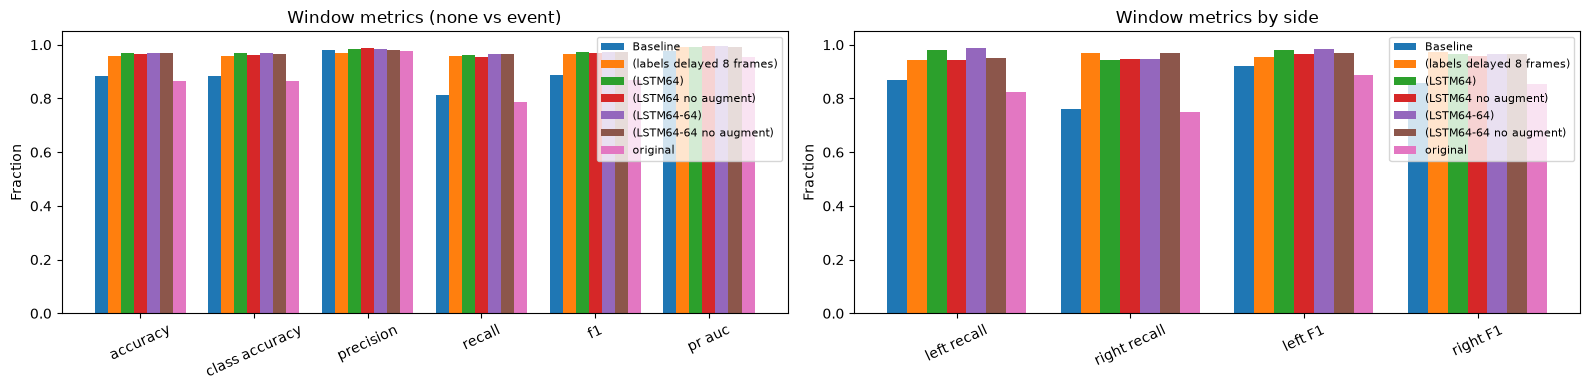

In [3]:
def grouped_bars(ax, table, columns, title, *, scale=1, ylabel='Score'):
    x = np.arange(len(columns))
    width = .8 / len(table)
    for i, (_, row) in enumerate(table.iterrows()):
        values = [row[column] * scale for column in columns]
        ax.bar(x - .4 + width*(i+.5), values, width, label=row['model'])
    ax.set(xticks=x, xticklabels=[name.replace('_', ' ') for name in columns],
           title=title, ylabel=ylabel)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

window_metrics = scores[scores.level == 'window'].copy()
overall = window_metrics[window_metrics.side == 'all']
by_side = window_metrics[window_metrics.side != 'all'].copy()
by_side['side_recall'] = by_side.side + ' recall'
by_side['side_f1'] = by_side.side + ' F1'
per_side = pd.concat([
    by_side.pivot(index='model', columns='side_recall', values='recall'),
    by_side.pivot(index='model', columns='side_f1', values='f1')], axis=1).reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
grouped_bars(axes[0], overall, ['accuracy', 'class_accuracy', 'precision', 'recall', 'f1', 'pr_auc'],
             'Window metrics (none vs event)', ylabel='Fraction')
grouped_bars(axes[1], per_side, [c for c in per_side if c != 'model'],
             'Window metrics by side', ylabel='Fraction')
for ax in axes: ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [4]:
window_metrics[['model', 'side', 'left_threshold', 'right_threshold', 'n_samples',
                'tp', 'fp', 'fn', 'tn', 'accuracy', 'class_accuracy', 'precision',
                'recall', 'f1', 'pr_auc', 'roc_auc']]  # Full table: window_metrics.

,model,side,left_threshold,right_threshold,n_samples,tp,fp,fn,tn,accuracy,class_accuracy,precision,recall,f1,pr_auc,roc_auc
0,Baseline,all,0.75,0.80,798.0,372.0,7.0,86.0,333.0,0.883459,0.883459,0.981530,0.812227,0.888889,0.975683,0.975610
1,Baseline,left,0.75,0.80,798.0,189.0,4.0,29.0,576.0,0.958647,NaN,0.979275,0.866972,0.919708,0.967385,0.989481
2,Baseline,right,0.75,0.80,798.0,183.0,3.0,57.0,555.0,0.924812,NaN,0.983871,0.762500,0.859155,0.979803,0.993698
9,(labels delayed 8 frames),all,0.70,0.60,798.0,439.0,14.0,19.0,326.0,0.958647,0.958647,0.969095,0.958515,0.963776,0.992450,0.990849
10,(labels delayed 8 frames),left,0.70,0.60,798.0,206.0,8.0,12.0,572.0,0.974937,NaN,0.962617,0.944954,0.953704,0.992251,0.997248
11,(labels delayed 8 frames),right,0.70,0.60,798.0,233.0,6.0,7.0,552.0,0.983709,NaN,0.974895,0.970833,0.972860,0.996367,0.998260
18,(LSTM64),all,0.65,0.75,798.0,440.0,7.0,18.0,333.0,0.968672,0.968672,0.984340,0.960699,0.972376,0.992332,0.991530
19,(LSTM64),left,0.65,0.75,798.0,214.0,5.0,4.0,575.0,0.988722,NaN,0.977169,0.981651,0.979405,0.991611,0.997303
20,(LSTM64),right,0.65,0.75,798.0,226.0,2.0,14.0,556.0,0.979950,NaN,0.991228,0.941667,0.965812,0.991685,0.996296
27,(LSTM64 no augment),all,0.50,0.65,798.0,437.0,5.0,21.0,335.0,0.967419,0.962406,0.988688,0.954148,0.971111,0.994975,0.993360


## Frame diagnostics
These per-frame values depend on the selected thresholds, except PR-AUC/ROC-AUC. Frames near the same physical event are correlated; streaming event results below are the primary product metrics.

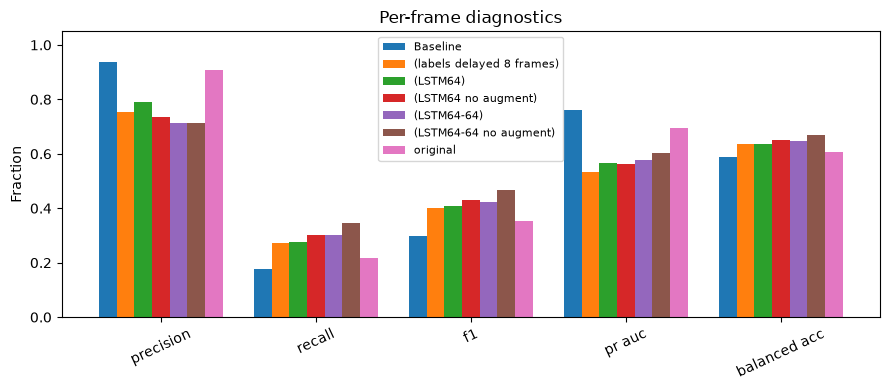

In [5]:
frame_metrics = scores[scores.level == 'frame'].copy()
fig, ax = plt.subplots(figsize=(9, 4))
grouped_bars(ax, frame_metrics[frame_metrics.side == 'all'],
             ['precision', 'recall', 'f1', 'pr_auc', 'balanced_acc'],
             'Per-frame diagnostics', ylabel='Fraction')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [6]:
frame_metrics[['model', 'side', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
               'n_samples', 'tp', 'fp', 'fn']]  # Full table: frame_metrics.

,model,side,precision,recall,f1,pr_auc,roc_auc,n_samples,tp,fp,fn
3,Baseline,all,0.937253,0.177023,0.297800,0.762287,0.983168,238129.0,1658.0,111.0,7708.0
4,Baseline,left,0.949168,0.226411,0.365611,0.771407,0.990008,238129.0,1027.0,55.0,3509.0
5,Baseline,right,0.918486,0.130642,0.228748,0.756469,0.990200,238129.0,631.0,56.0,4199.0
12,(labels delayed 8 frames),all,0.752865,0.273543,0.401284,0.531744,0.940701,238129.0,2562.0,841.0,6804.0
13,(labels delayed 8 frames),left,0.721967,0.242725,0.363306,0.481600,0.953442,238129.0,1101.0,424.0,3435.0
14,(labels delayed 8 frames),right,0.777955,0.302484,0.435599,0.592109,0.976674,238129.0,1461.0,417.0,3369.0
21,(LSTM64),all,0.789409,0.275358,0.408296,0.565602,0.947804,238129.0,2579.0,688.0,6787.0
22,(LSTM64),left,0.765888,0.310847,0.442214,0.540795,0.961369,238129.0,1410.0,431.0,3126.0
23,(LSTM64),right,0.817672,0.241408,0.372762,0.576184,0.968188,238129.0,1166.0,260.0,3664.0
30,(LSTM64 no augment),all,0.734541,0.303118,0.429144,0.562189,0.946239,238129.0,2839.0,1026.0,6527.0


## Streaming event detection
Event matching is class-aware, one-to-one, and uses the **actual alarm-emission frame**. FP/min counts unmatched alarms over all validation minutes, including early and wrong-side alarms. The selected operating point can differ per model even though its selection mode is the same.

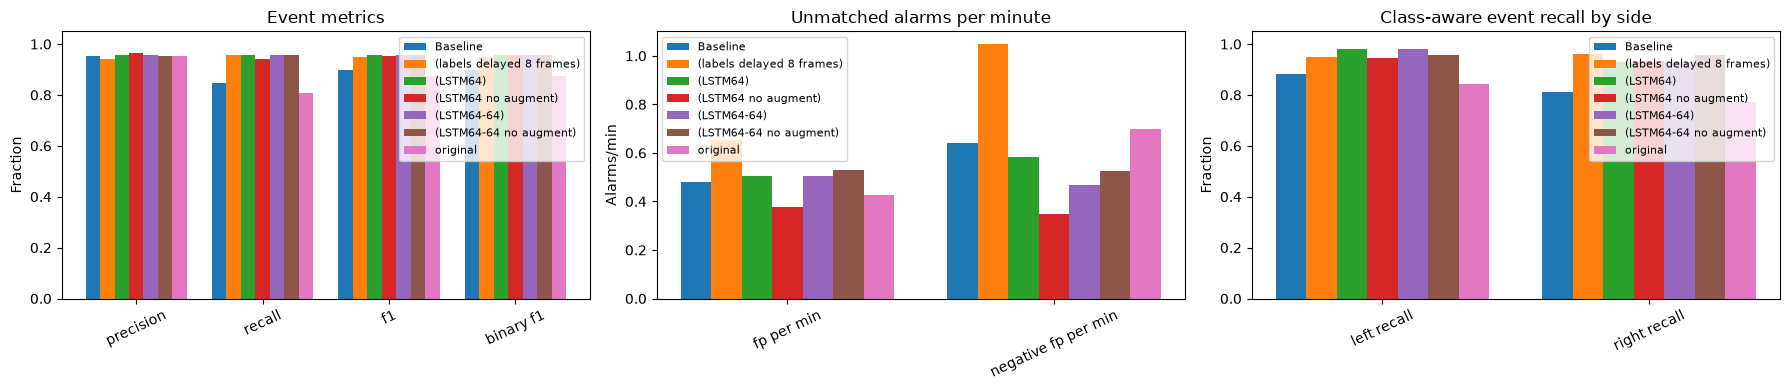

In [7]:
event_metrics = scores[scores.level == 'event'].copy()
event_overall = event_metrics[event_metrics.side == 'all']
event_side = event_metrics[event_metrics.side != 'all'].copy()
event_side['side_recall'] = event_side.side + ' recall'
side_recall = event_side.pivot(index='model', columns='side_recall', values='recall').reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
grouped_bars(axes[0], event_overall, ['precision', 'recall', 'f1', 'binary_f1'],
             'Event metrics', ylabel='Fraction')
grouped_bars(axes[1], event_overall, ['fp_per_min', 'negative_fp_per_min'],
             'Unmatched alarms per minute', ylabel='Alarms/min')
grouped_bars(axes[2], side_recall, [c for c in side_recall if c != 'model'],
             'Class-aware event recall by side', ylabel='Fraction')
axes[0].set_ylim(0, 1.05)
axes[2].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [8]:
event_metrics[['model', 'side', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1',
               'binary_f1', 'fp_per_min', 'negative_fp_per_min',
               'left_threshold', 'right_threshold']]  # Full table: event_metrics.

,model,side,tp,fp,fn,precision,recall,f1,binary_f1,fp_per_min,negative_fp_per_min,left_threshold,right_threshold
6,Baseline,all,378.0,19.0,68.0,0.952141,0.847534,0.896797,0.896797,0.478732,0.640721,0.75,0.80
7,Baseline,left,191.0,9.0,25.0,0.955000,0.884259,0.918269,NaN,0.226768,0.407731,0.75,0.80
8,Baseline,right,187.0,10.0,43.0,0.949239,0.813043,0.875878,NaN,0.251964,0.232989,0.75,0.80
15,(labels delayed 8 frames),all,426.0,26.0,20.0,0.942478,0.955157,0.948775,0.948775,0.655107,1.048452,0.70,0.60
16,(labels delayed 8 frames),left,205.0,14.0,11.0,0.936073,0.949074,0.942529,NaN,0.352750,0.698968,0.70,0.60
17,(labels delayed 8 frames),right,221.0,12.0,9.0,0.948498,0.960870,0.954644,NaN,0.302357,0.349484,0.70,0.60
24,(LSTM64),all,426.0,20.0,20.0,0.955157,0.955157,0.955157,0.957399,0.503929,0.582473,0.65,0.75
25,(LSTM64),left,212.0,8.0,4.0,0.963636,0.981481,0.972477,NaN,0.201571,0.349484,0.65,0.75
26,(LSTM64),right,214.0,12.0,16.0,0.946903,0.930435,0.938596,NaN,0.302357,0.232989,0.65,0.75
33,(LSTM64 no augment),all,419.0,15.0,27.0,0.965438,0.939462,0.952273,0.956818,0.377946,0.349484,0.50,0.65


## Alarm latency
Deadline recall is the fraction of **all annotated events** detected before X frames (misses remain in the denominator). Mean/median/p90 latency includes matched events only and can be misleading if recall is low.

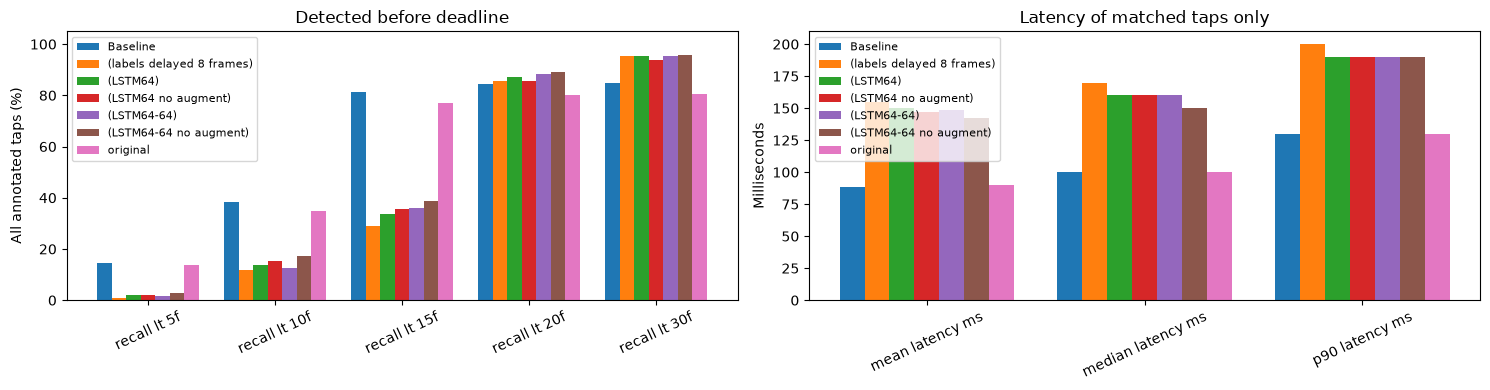

In [9]:
latency_metrics = event_overall[['model', 'left_threshold', 'right_threshold',
                                 'recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f',
                                 'recall_lt_20f', 'recall_lt_30f', 'mean_latency_ms',
                                 'median_latency_ms', 'p90_latency_ms', 'tp', 'fn']].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
grouped_bars(axes[0], latency_metrics,
             ['recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f', 'recall_lt_20f', 'recall_lt_30f'],
             'Detected before deadline', scale=100, ylabel='All annotated taps (%)')
grouped_bars(axes[1], latency_metrics,
             ['mean_latency_ms', 'median_latency_ms', 'p90_latency_ms'],
             'Latency of matched taps only', ylabel='Milliseconds')
axes[0].set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [10]:
latency_metrics  # Filter model and compare recall/latency at the same deadline.

,model,left_threshold,right_threshold,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f,mean_latency_ms,median_latency_ms,p90_latency_ms,tp,fn
6,Baseline,0.75,0.80,0.145740,0.383408,0.813901,0.845291,0.847534,88.650794,100.0,130.0,378.0,68.0
15,(labels delayed 8 frames),0.70,0.60,0.008969,0.118834,0.289238,0.854260,0.955157,155.000000,170.0,200.0,426.0,20.0
24,(LSTM64),0.65,0.75,0.020179,0.139013,0.338565,0.872197,0.955157,150.492958,160.0,190.0,426.0,20.0
33,(LSTM64 no augment),0.50,0.65,0.020179,0.152466,0.356502,0.856502,0.939462,147.207637,160.0,190.0,419.0,27.0
42,(LSTM64-64),0.55,0.75,0.017937,0.125561,0.358744,0.883408,0.955157,148.920188,160.0,190.0,426.0,20.0
51,(LSTM64-64 no augment),0.55,0.65,0.029148,0.172646,0.387892,0.890135,0.957399,141.990632,150.0,190.0,427.0,19.0
60,original,0.65,0.80,0.139013,0.347534,0.771300,0.800448,0.807175,90.055556,100.0,130.0,360.0,86.0


## Recording types and individual files
Rows use the same selected policy and left/right thresholds as the event and window plots. Negative-only types have undefined event recall; their FP/min and false-positive window rates are the useful metrics. Grouped by type, every value is pooled over its files (not an average of file percentages). Some types contain only one file.

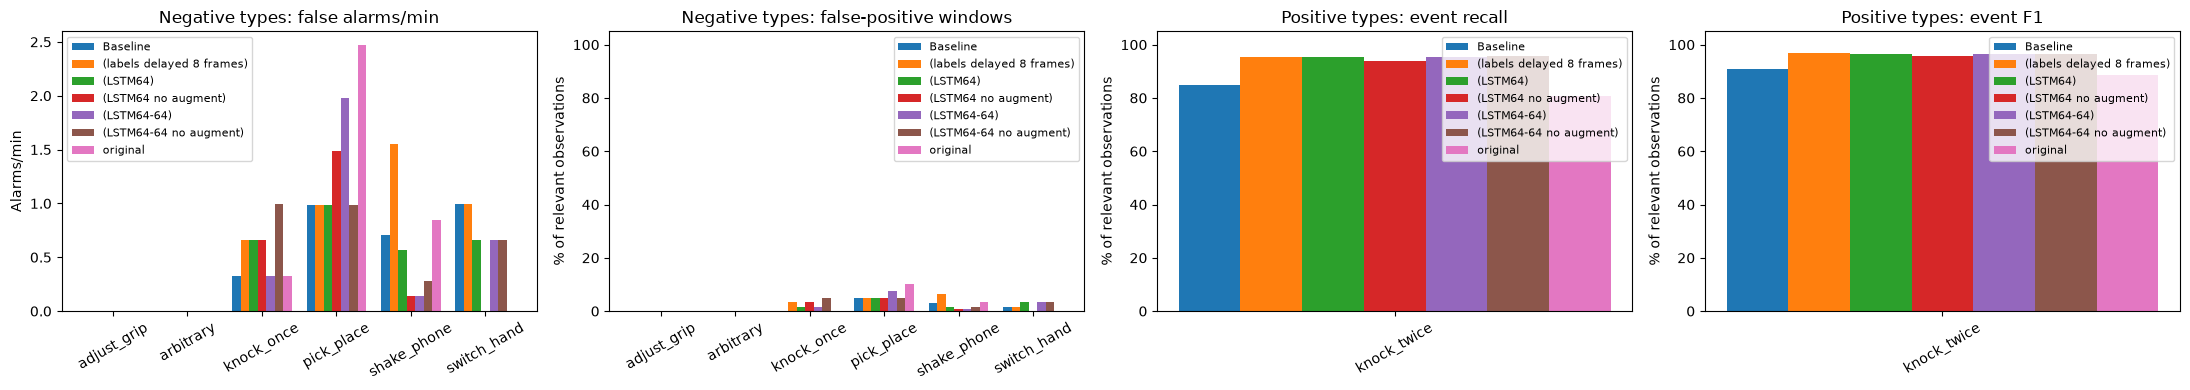

In [11]:
type_comparison = type_scores.copy()
negative = type_comparison[type_comparison.n_true_events == 0]
positive = type_comparison[type_comparison.n_true_events > 0]
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, subset, metric, title, scale in [
        (axes[0], negative, 'event_fp_per_min', 'Negative types: false alarms/min', 1),
        (axes[1], negative, 'window_false_positive_rate', 'Negative types: false-positive windows', 100),
        (axes[2], positive, 'event_recall', 'Positive types: event recall', 100),
        (axes[3], positive, 'event_f1', 'Positive types: event F1', 100)]:
    x = sorted(subset.recording_type.unique())
    width = .8 / len(RUNS)
    for i, label in enumerate(RUNS):
        rows = subset[subset.model == label].set_index('recording_type').reindex(x)
        ax.bar(np.arange(len(x)) - .4 + width*(i+.5), rows[metric] * scale, width, label=label)
    ax.set(xticks=np.arange(len(x)), xticklabels=x, title=title)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Alarms/min')
for ax in axes[1:]: ax.set(ylabel='% of relevant observations', ylim=(0, 105))
plt.tight_layout()
plt.show()

In [12]:
type_comparison[['model', 'recording_type', 'recordings', 'n_windows', 'n_true_events',
                 'event_tp', 'event_fp', 'event_fn', 'event_f1', 'event_fp_per_min',
                 'event_left_recall', 'event_right_recall', 'window_accuracy',
                 'window_false_positive_rate']]  # Full table: type_comparison.

,model,recording_type,recordings,n_windows,n_true_events,event_tp,event_fp,event_fn,event_f1,event_fp_per_min,event_left_recall,event_right_recall,window_accuracy,window_false_positive_rate
0,Baseline,adjust_grip,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
1,Baseline,arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
2,Baseline,knock_once,3,60,0,0,1,0,0.000000,0.330196,NaN,NaN,1.000000,0.000000
3,Baseline,knock_twice,23,458,446,378,8,68,0.908654,0.355240,0.884259,0.813043,0.812227,NaN
4,Baseline,pick_place,2,40,0,0,2,0,0.000000,0.989691,NaN,NaN,0.950000,0.050000
5,Baseline,shake_phone,7,140,0,0,5,0,0.000000,0.707347,NaN,NaN,0.971429,0.028571
6,Baseline,switch_hand,3,60,0,0,3,0,0.000000,0.990208,NaN,NaN,0.983333,0.016667
7,(labels delayed 8 frames),adjust_grip,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
8,(labels delayed 8 frames),arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
9,(labels delayed 8 frames),knock_once,3,60,0,0,2,0,0.000000,0.660393,NaN,NaN,0.966667,0.033333


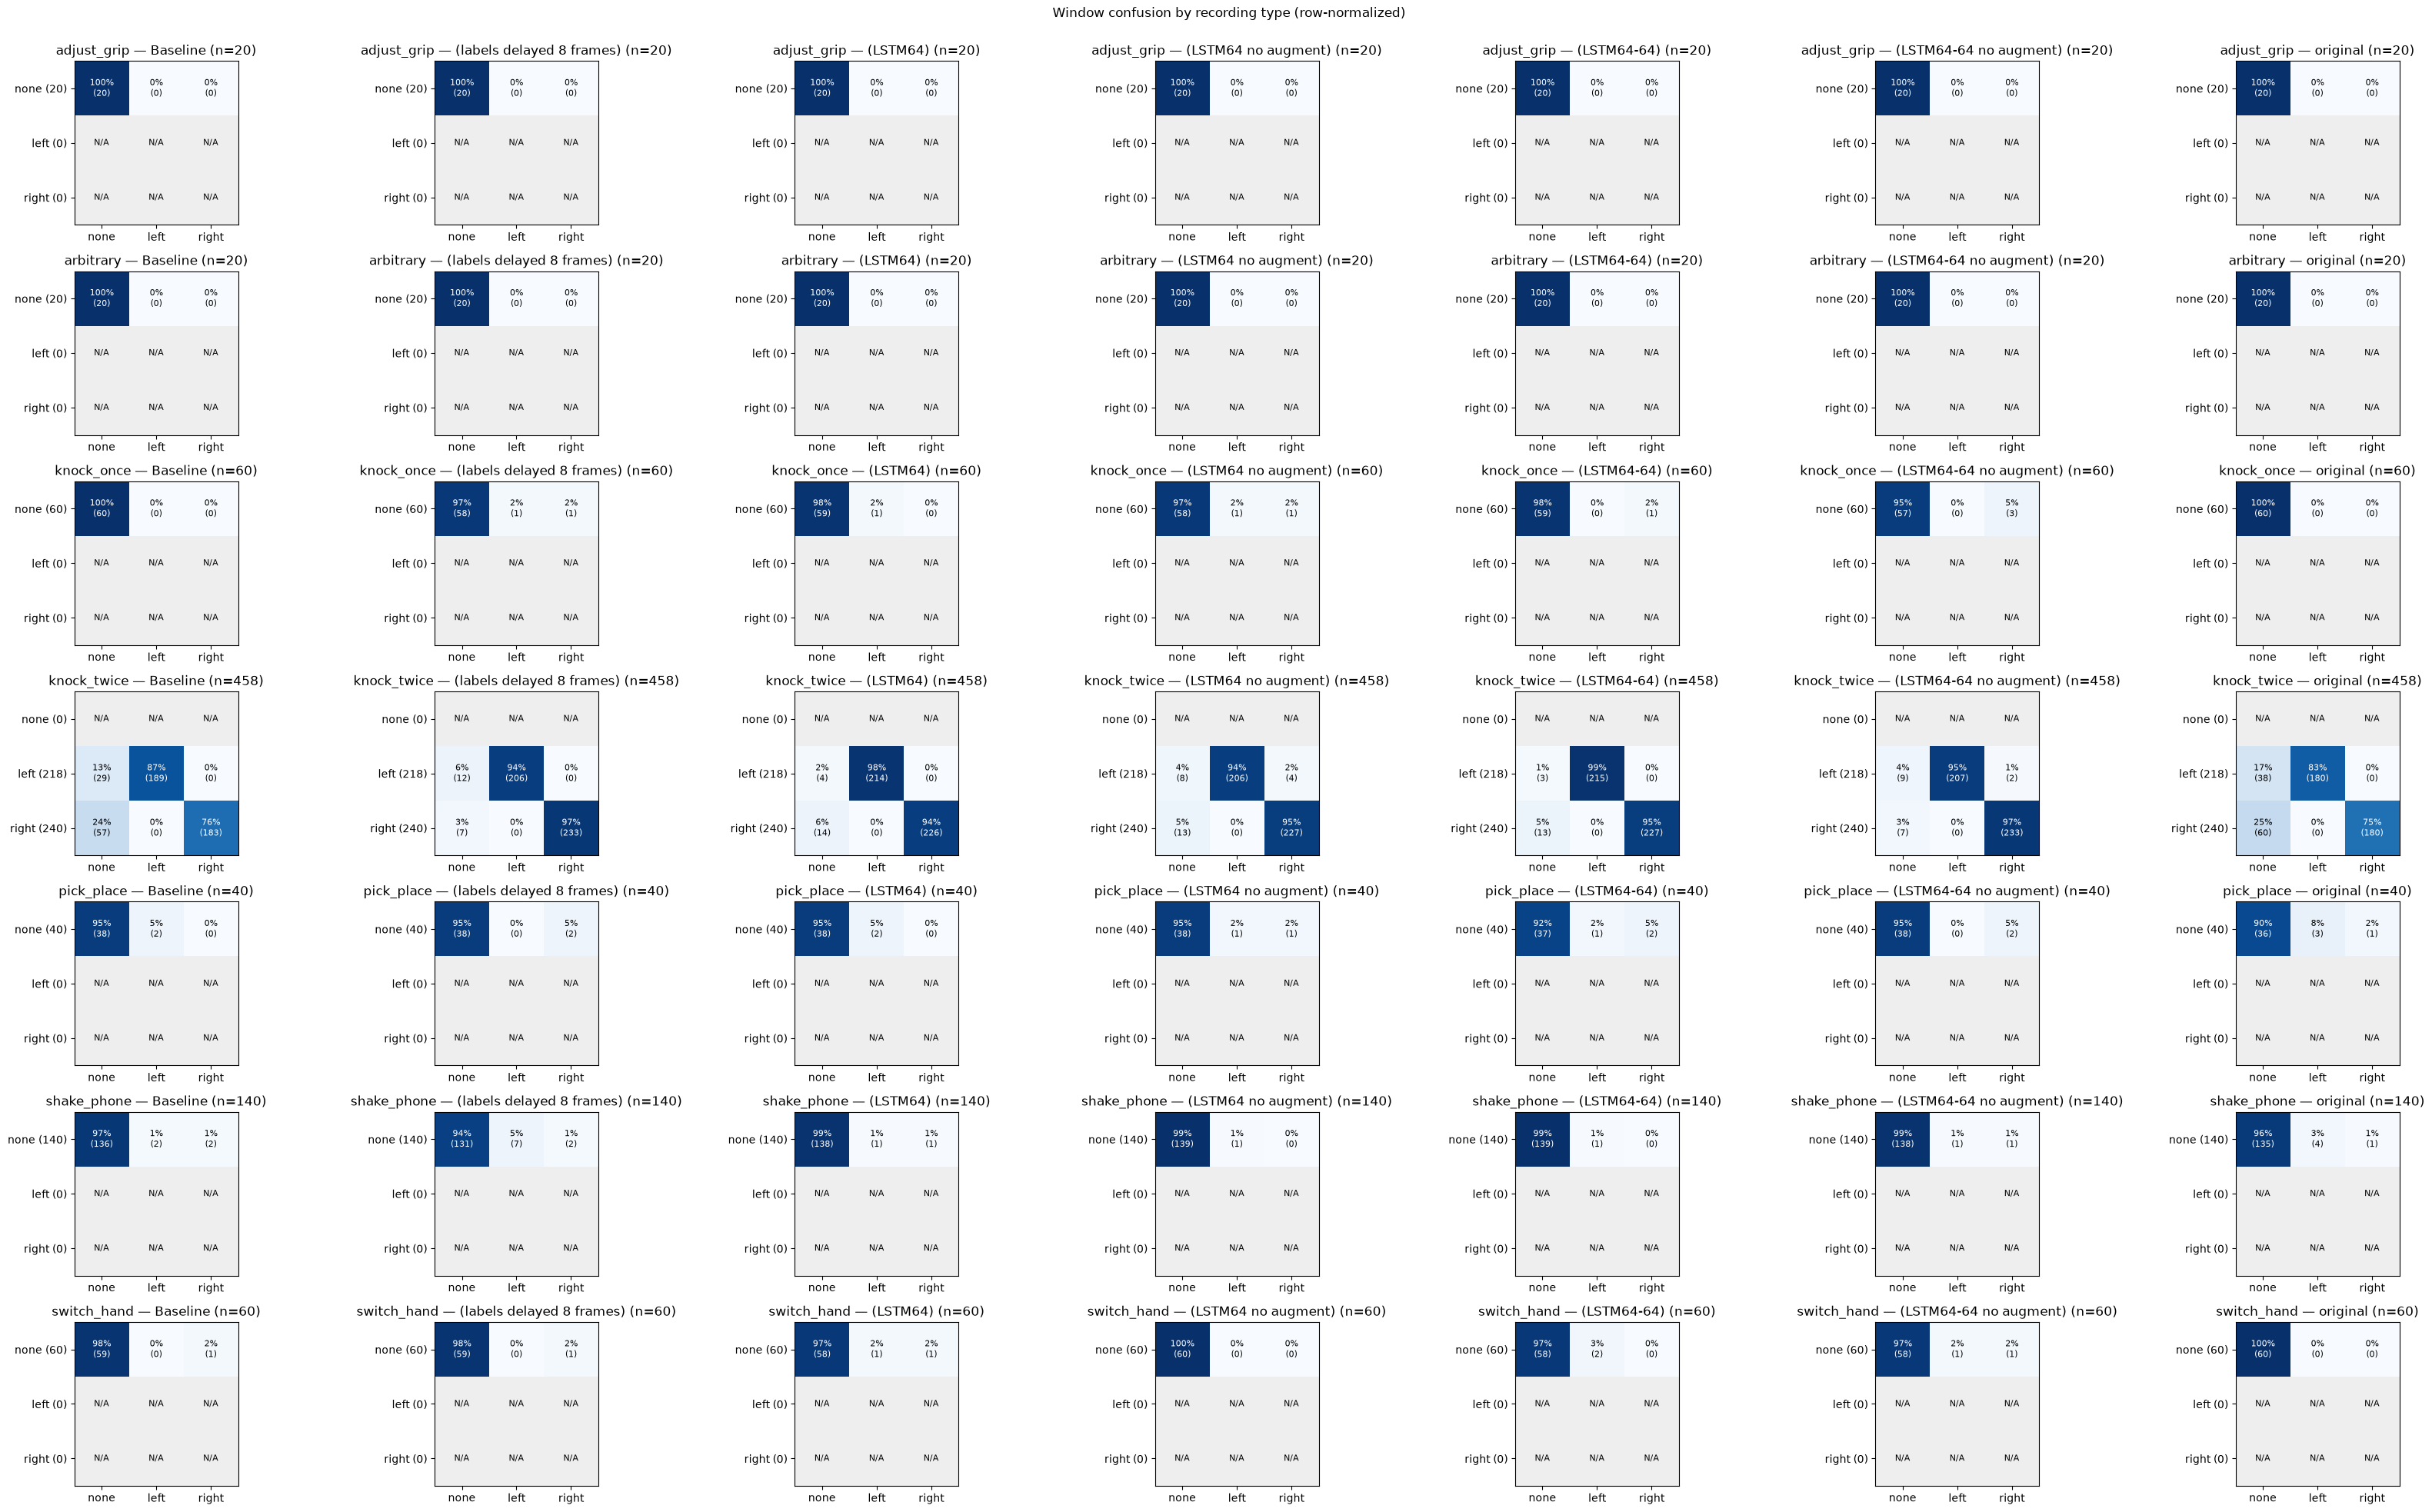

In [13]:
from matplotlib.colors import Normalize
confusion_rows = []
recording_types = sorted(expected_types)
fig, axes = plt.subplots(len(recording_types), len(RUNS),
                         figsize=(4.8*len(RUNS), 2.8*len(recording_types)), squeeze=False)
colors = plt.get_cmap('Blues').copy()
colors.set_bad('#eeeeee')
for i, recording_type in enumerate(recording_types):
    for j, model_name in enumerate(RUNS):
        row = type_comparison[(type_comparison.recording_type == recording_type) &
                              (type_comparison.model == model_name)].iloc[0]
        cm = np.array([[int(row[f'cm_{t}{p}']) for p in range(3)] for t in range(3)])
        totals = cm.sum(axis=1)
        fractions = np.divide(cm, totals[:, None], out=np.full((3, 3), np.nan),
                              where=totals[:, None] > 0)
        ax = axes[i, j]
        ax.imshow(np.ma.masked_invalid(fractions), cmap=colors, norm=Normalize(0, 1))
        ax.set(title=f'{recording_type} — {model_name} (n={cm.sum()})',
               xticks=range(3), xticklabels=('none', 'left', 'right'),
               yticks=range(3), yticklabels=[f'{name} ({n})' for name, n in
                                        zip(('none', 'left', 'right'), totals)])
        for t, true_class in enumerate(('none', 'left', 'right')):
            for p, predicted_class in enumerate(('none', 'left', 'right')):
                ax.text(p, t, f'{fractions[t, p]:.0%}\n({cm[t, p]})' if totals[t] else 'N/A',
                        ha='center', va='center', fontsize=8,
                        color='white' if totals[t] and fractions[t, p] > .55 else 'black')
                confusion_rows.append(dict(model=model_name, recording_type=recording_type,
                                           true_class=true_class, predicted_class=predicted_class,
                                           count=int(cm[t, p]), true_count=int(totals[t]),
                                           row_fraction=fractions[t, p]))
fig.suptitle('Window confusion by recording type (row-normalized)', y=1.001)
plt.tight_layout()
plt.show()
type_confusion_comparison = pd.DataFrame(confusion_rows)

In [14]:
type_confusion_comparison  # N/A rows have no observed examples of that true class.

,model,recording_type,true_class,predicted_class,count,true_count,row_fraction
0,Baseline,adjust_grip,none,none,20,20,1.0
1,Baseline,adjust_grip,none,left,0,20,0.0
2,Baseline,adjust_grip,none,right,0,20,0.0
3,Baseline,adjust_grip,left,none,0,0,NaN
4,Baseline,adjust_grip,left,left,0,0,NaN
...,...,...,...,...,...,...,...
436,original,switch_hand,left,left,0,0,NaN
437,original,switch_hand,left,right,0,0,NaN
438,original,switch_hand,right,none,0,0,NaN
439,original,switch_hand,right,left,0,0,NaN


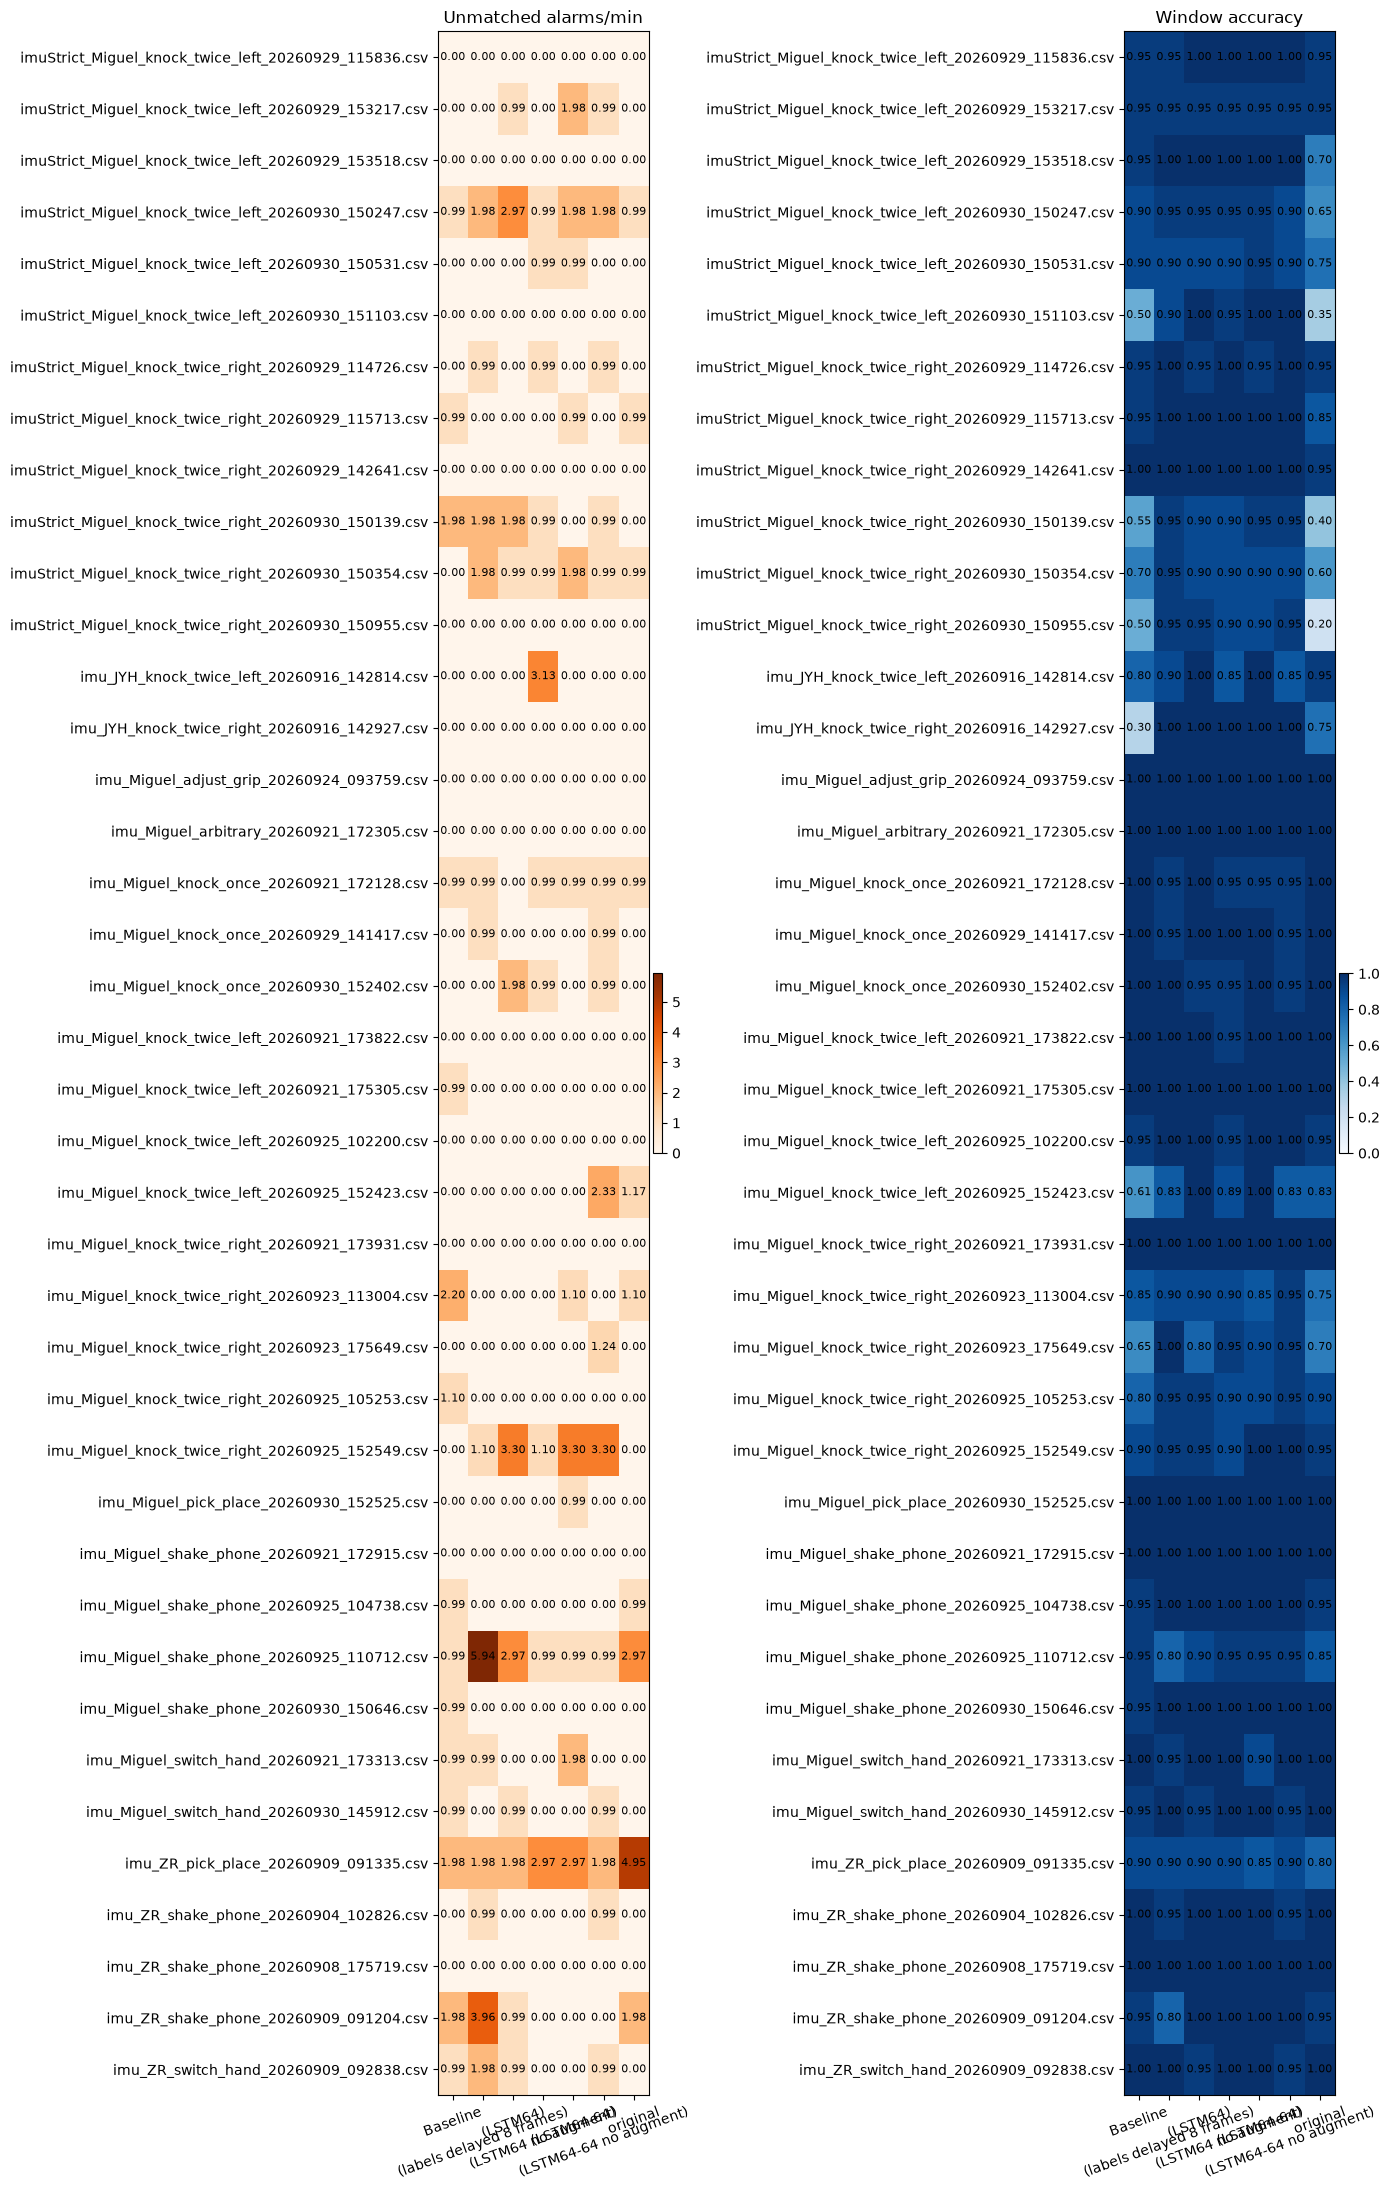

In [15]:
recording_comparison = file_scores.copy()
files = sorted(recording_comparison.file.unique())
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, .55*len(files))))
for ax, field, label, cmap in [
        (axes[0], 'event_fp_per_min', 'Unmatched alarms/min', 'Oranges'),
        (axes[1], 'window_accuracy', 'Window accuracy', 'Blues')]:
    table = recording_comparison.pivot(index='file', columns='model', values=field).reindex(
        index=files, columns=list(RUNS))
    data = table.to_numpy(dtype=float)
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=0, vmax=1 if field == 'window_accuracy' else None)
    ax.set(yticks=np.arange(len(files)), yticklabels=files, xticks=np.arange(len(RUNS)),
           xticklabels=list(RUNS), title=label)
    ax.tick_params(axis='x', rotation=20)
    for i in range(len(files)):
        for j in range(len(RUNS)):
            ax.text(j, i, f'{data[i, j]:.2f}',
                    ha='center', va='center', color='black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=.04, pad=.02)
plt.tight_layout()
plt.show()

In [16]:
recording_comparison[['model', 'file', 'recording_type', 'n_windows',
                      'n_true_events', 'event_tp', 'event_fp', 'event_fn',
                      'window_fp', 'window_fn', 'event_fp_per_min', 'minutes']]  # Full table: recording_comparison.

,model,file,recording_type,n_windows,n_true_events,event_tp,event_fp,event_fn,window_fp,window_fn,event_fp_per_min,minutes
0,Baseline,imuStrict_Miguel_knock_twice_left_20260929_115...,knock_twice,20,20,19,0,1,0,1,0.000000,1.010500
1,Baseline,imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,19,0,1,0,1,0.000000,1.010167
2,Baseline,imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,19,0,1,0,1,0.000000,1.010667
3,Baseline,imuStrict_Miguel_knock_twice_left_20260930_150...,knock_twice,20,20,17,1,3,0,2,0.989609,1.010500
4,Baseline,imuStrict_Miguel_knock_twice_left_20260930_150...,knock_twice,20,20,18,0,2,0,2,0.000000,1.009667
...,...,...,...,...,...,...,...,...,...,...,...,...
275,original,imu_ZR_pick_place_20260909_091335.csv,pick_place,20,0,0,5,0,4,0,4.948862,1.010333
276,original,imu_ZR_shake_phone_20260904_102826.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.008833
277,original,imu_ZR_shake_phone_20260908_175719.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.009000
278,original,imu_ZR_shake_phone_20260909_091204.csv,shake_phone,20,0,0,2,0,1,0,1.978892,1.010667


## Inspect individual validation examples (current recordings)
The saved exports above contain per-recording totals, but not individual segment predictions or probability traces. The next cell replays each selected `best.pt` on **the current validation files** at its saved left/right thresholds, with the same window fitting, continuous causal inference, class-aware event matching, and alarm policy as the evaluator. It does not tune thresholds. `example_data_status` shows whether today's raw CSVs, label text files, and exclusion registry still match the original exports. If not, the detailed tables below describe *current-data replay* and must not be mixed with the historical exported totals above.

`segment_scores` and `recording_scores` are long-form filterable tables; `segment_matrix` and `recording_matrix` put each model in its own column group. Segment IDs are the CSV's `segment_index` (not window row numbers). Event TP/FP/FN use one-to-one matching on the **whole recording** before attribution to a segment; `too_early_fp` counts unmatched alarms emitted too early for their nearest tap, while `wrong_side_fp` is an unmatched alarm that matched in the side-agnostic check. Window classification is separate from alarm matching. Excluded segments and unlabeled windows are not scored.


In [17]:
import sys
sys.path.insert(0, str(ROOT))
import torch
from notebooks_analysis.model_comparison_examples import (
    comparison_matrix, plot_example, replay_examples,
)

torch.set_num_threads(2)
detail_points = operating_points.merge(comparison_sources[['model', 'folder']],
                                       on='model', validate='one_to_one')
example_recordings, example_traces, segment_scores, recording_scores, alarm_details, example_data_status = (
    replay_examples(ROOT, detail_points)
)
display(example_data_status)
print('Detailed replay:', len(segment_scores), 'model/segment rows,',
      len(recording_scores), 'model/recording rows,', len(alarm_details), 'alarms')

  Excluding session(s) [4] from imu_JYH_knock_twice_left_20260916_142814.csv
  Excluding session(s) [3, 5, 7] from imu_Miguel_knock_twice_left_20260925_152423.csv
  Excluding session(s) [17, 18] from imu_Miguel_knock_twice_right_20260923_113004.csv
  Excluding session(s) [4, 8, 12, 19] from imu_Miguel_knock_twice_right_20260923_175649.csv
  Excluding session(s) [18, 20] from imu_Miguel_knock_twice_right_20260925_105253.csv
  Excluding session(s) [10, 17] from imu_Miguel_knock_twice_right_20260925_152549.csv


,model,split,export_validation_sha256,current_validation_sha256,matches_export
0,Baseline,valid,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,24c4b3976c77e7c36ca780da1adc471b1fcb8fd683d0d6...,False
1,(labels delayed 8 frames),valid,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,24c4b3976c77e7c36ca780da1adc471b1fcb8fd683d0d6...,False
2,(LSTM64),valid,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,24c4b3976c77e7c36ca780da1adc471b1fcb8fd683d0d6...,False
3,(LSTM64 no augment),valid,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,24c4b3976c77e7c36ca780da1adc471b1fcb8fd683d0d6...,False
4,(LSTM64-64),valid,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,24c4b3976c77e7c36ca780da1adc471b1fcb8fd683d0d6...,False
5,(LSTM64-64 no augment),valid,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,24c4b3976c77e7c36ca780da1adc471b1fcb8fd683d0d6...,False
6,original,valid,54658f37c037c4cdcc564d2ac5ba315f44815f9e709fb4...,24c4b3976c77e7c36ca780da1adc471b1fcb8fd683d0d6...,False


Detailed replay: 5502 model/segment rows, 280 model/recording rows, 2999 alarms


### Find difficult segments and recordings
Filter `segment_scores.query("recording_type == 'knock_twice' and event_fn > 0")` for missed double taps or `segment_scores.query('too_early_fp > 0 or wrong_side_fp > 0')` for premature/wrong-side alarms. `alarm_details` gives each alarm's global emission/peak frame, closest annotation, matched status, and segment ID. `recording_scores` includes both knock-twice recordings and negative-only activity; its `event_fp_per_min` uses the sum of **included** segment durations. Edit the displayed slices or filter `segment_matrix.loc[('filename.csv', 8)]` / `recording_matrix.loc['filename.csv']` to see every model together.


In [25]:

    

segment_matrix = comparison_matrix(segment_scores, ['file', 'segment_index'],
    ['window_true', 'window_pred', 'window_correct', 'window_fp', 'window_fn',
     'p_left_max', 'p_right_max', 'event_tp', 'event_fp', 'event_fn',
     'too_early_fp', 'wrong_side_fp', 'latency_frames'])
recording_matrix = comparison_matrix(recording_scores, ['file'],
    ['recording_type', 'minutes', 'n_windows', 'window_accuracy', 'window_fp', 'window_fn',
     'n_true_events', 'event_tp', 'event_fp', 'event_fn', 'too_early_fp',
     'wrong_side_fp', 'event_fp_per_min'])
segment_difficulty = segment_scores.groupby(['file', 'segment_index', 'recording_type'],
    as_index=False).agg(models_missing=('event_fn', lambda x: (x > 0).sum()),
                        models_false_alarm=('event_fp', lambda x: (x > 0).sum()),
                        models_window_wrong=('window_correct', lambda x: (x == False).sum()),
                        too_early_fp=('too_early_fp', 'sum'), wrong_side_fp=('wrong_side_fp', 'sum'))
print('Hard double-tap segments (one row per CSV segment):')
with pd.option_context('display.max_colwidth', None):
    display(segment_difficulty.query("recording_type == 'knock_twice'")
        .sort_values(['models_missing', 'too_early_fp', 'models_false_alarm'],
                     ascending=False).head(25))
print('Hard recordings (one row per model/recording):')
with pd.option_context('display.max_colwidth', None):
    display(recording_scores.sort_values(['event_fp_per_min', 'event_fn'], ascending=False)
        [['model', 'file', 'recording_type', 'n_true_events', 'event_tp', 'event_fp',
          'event_fn', 'too_early_fp', 'window_fp', 'event_fp_per_min']].head(25))

Hard double-tap segments (one row per CSV segment):


,file,segment_index,recording_type,models_missing,models_false_alarm,models_window_wrong,too_early_fp,wrong_side_fp
535,imu_Miguel_knock_twice_right_20260925_152549.csv,8,knock_twice,7,3,4,3,0
129,imuStrict_Miguel_knock_twice_right_20260929_114726.csv,10,knock_twice,7,3,4,0,0
80,imuStrict_Miguel_knock_twice_left_20260930_150531.csv,1,knock_twice,7,2,6,0,0
492,imu_Miguel_knock_twice_right_20260923_113004.csv,19,knock_twice,7,1,6,0,0
90,imuStrict_Miguel_knock_twice_left_20260930_150531.csv,11,knock_twice,7,0,7,0,0
198,imuStrict_Miguel_knock_twice_right_20260930_150139.csv,19,knock_twice,7,0,7,0,0
212,imuStrict_Miguel_knock_twice_right_20260930_150354.csv,13,knock_twice,7,0,7,0,0
239,imuStrict_Miguel_knock_twice_right_20260930_150955.csv,20,knock_twice,7,0,7,0,0
21,imuStrict_Miguel_knock_twice_left_20260929_153217.csv,2,knock_twice,6,0,7,0,0
60,imuStrict_Miguel_knock_twice_left_20260930_150247.csv,1,knock_twice,6,0,6,0,0


Hard recordings (one row per model/recording):


,model,file,recording_type,n_true_events,event_tp,event_fp,event_fn,too_early_fp,window_fp,event_fp_per_min
191,(labels delayed 8 frames),imu_Miguel_shake_phone_20260925_110712.csv,shake_phone,0,0,6,0,0,4,5.940594
275,original,imu_ZR_pick_place_20260909_091335.csv,pick_place,0,0,5,0,0,4,4.948862
198,(labels delayed 8 frames),imu_ZR_shake_phone_20260909_091204.csv,shake_phone,0,0,4,0,0,4,3.957784
67,(LSTM64),imu_Miguel_knock_twice_right_20260925_152549.csv,knock_twice,18,14,3,4,1,0,3.299120
147,(LSTM64-64),imu_Miguel_knock_twice_right_20260925_152549.csv,knock_twice,18,15,3,3,1,0,3.299120
107,(LSTM64-64 no augment),imu_Miguel_knock_twice_right_20260925_152549.csv,knock_twice,18,16,3,2,1,0,3.299120
12,(LSTM64 no augment),imu_JYH_knock_twice_left_20260916_142814.csv,knock_twice,19,16,3,3,1,0,3.130435
71,(LSTM64),imu_Miguel_shake_phone_20260925_110712.csv,shake_phone,0,0,3,0,0,2,2.970297
271,original,imu_Miguel_shake_phone_20260925_110712.csv,shake_phone,0,0,3,0,0,3,2.970297
35,(LSTM64 no augment),imu_ZR_pick_place_20260909_091335.csv,pick_place,0,0,3,0,0,2,2.969317


### Aligned recording/segment inspection
Choose a `file` and optionally a `segment_index` from the tables. The top row shows acceleration deviation and gyro magnitude from the original CSV; the following rows show each model's left/right probabilities, dotted operating thresholds, annotated second taps (dashed), and emitted alarms (triangles; red edges are unmatched alarms). All rows share the original recording's time axis. Use `REVIEW_SEGMENT = None` to inspect an entire recording.


,model,file,segment_index,window_true,window_pred,event_tp,event_fp,event_fn,too_early_fp,latency_frames


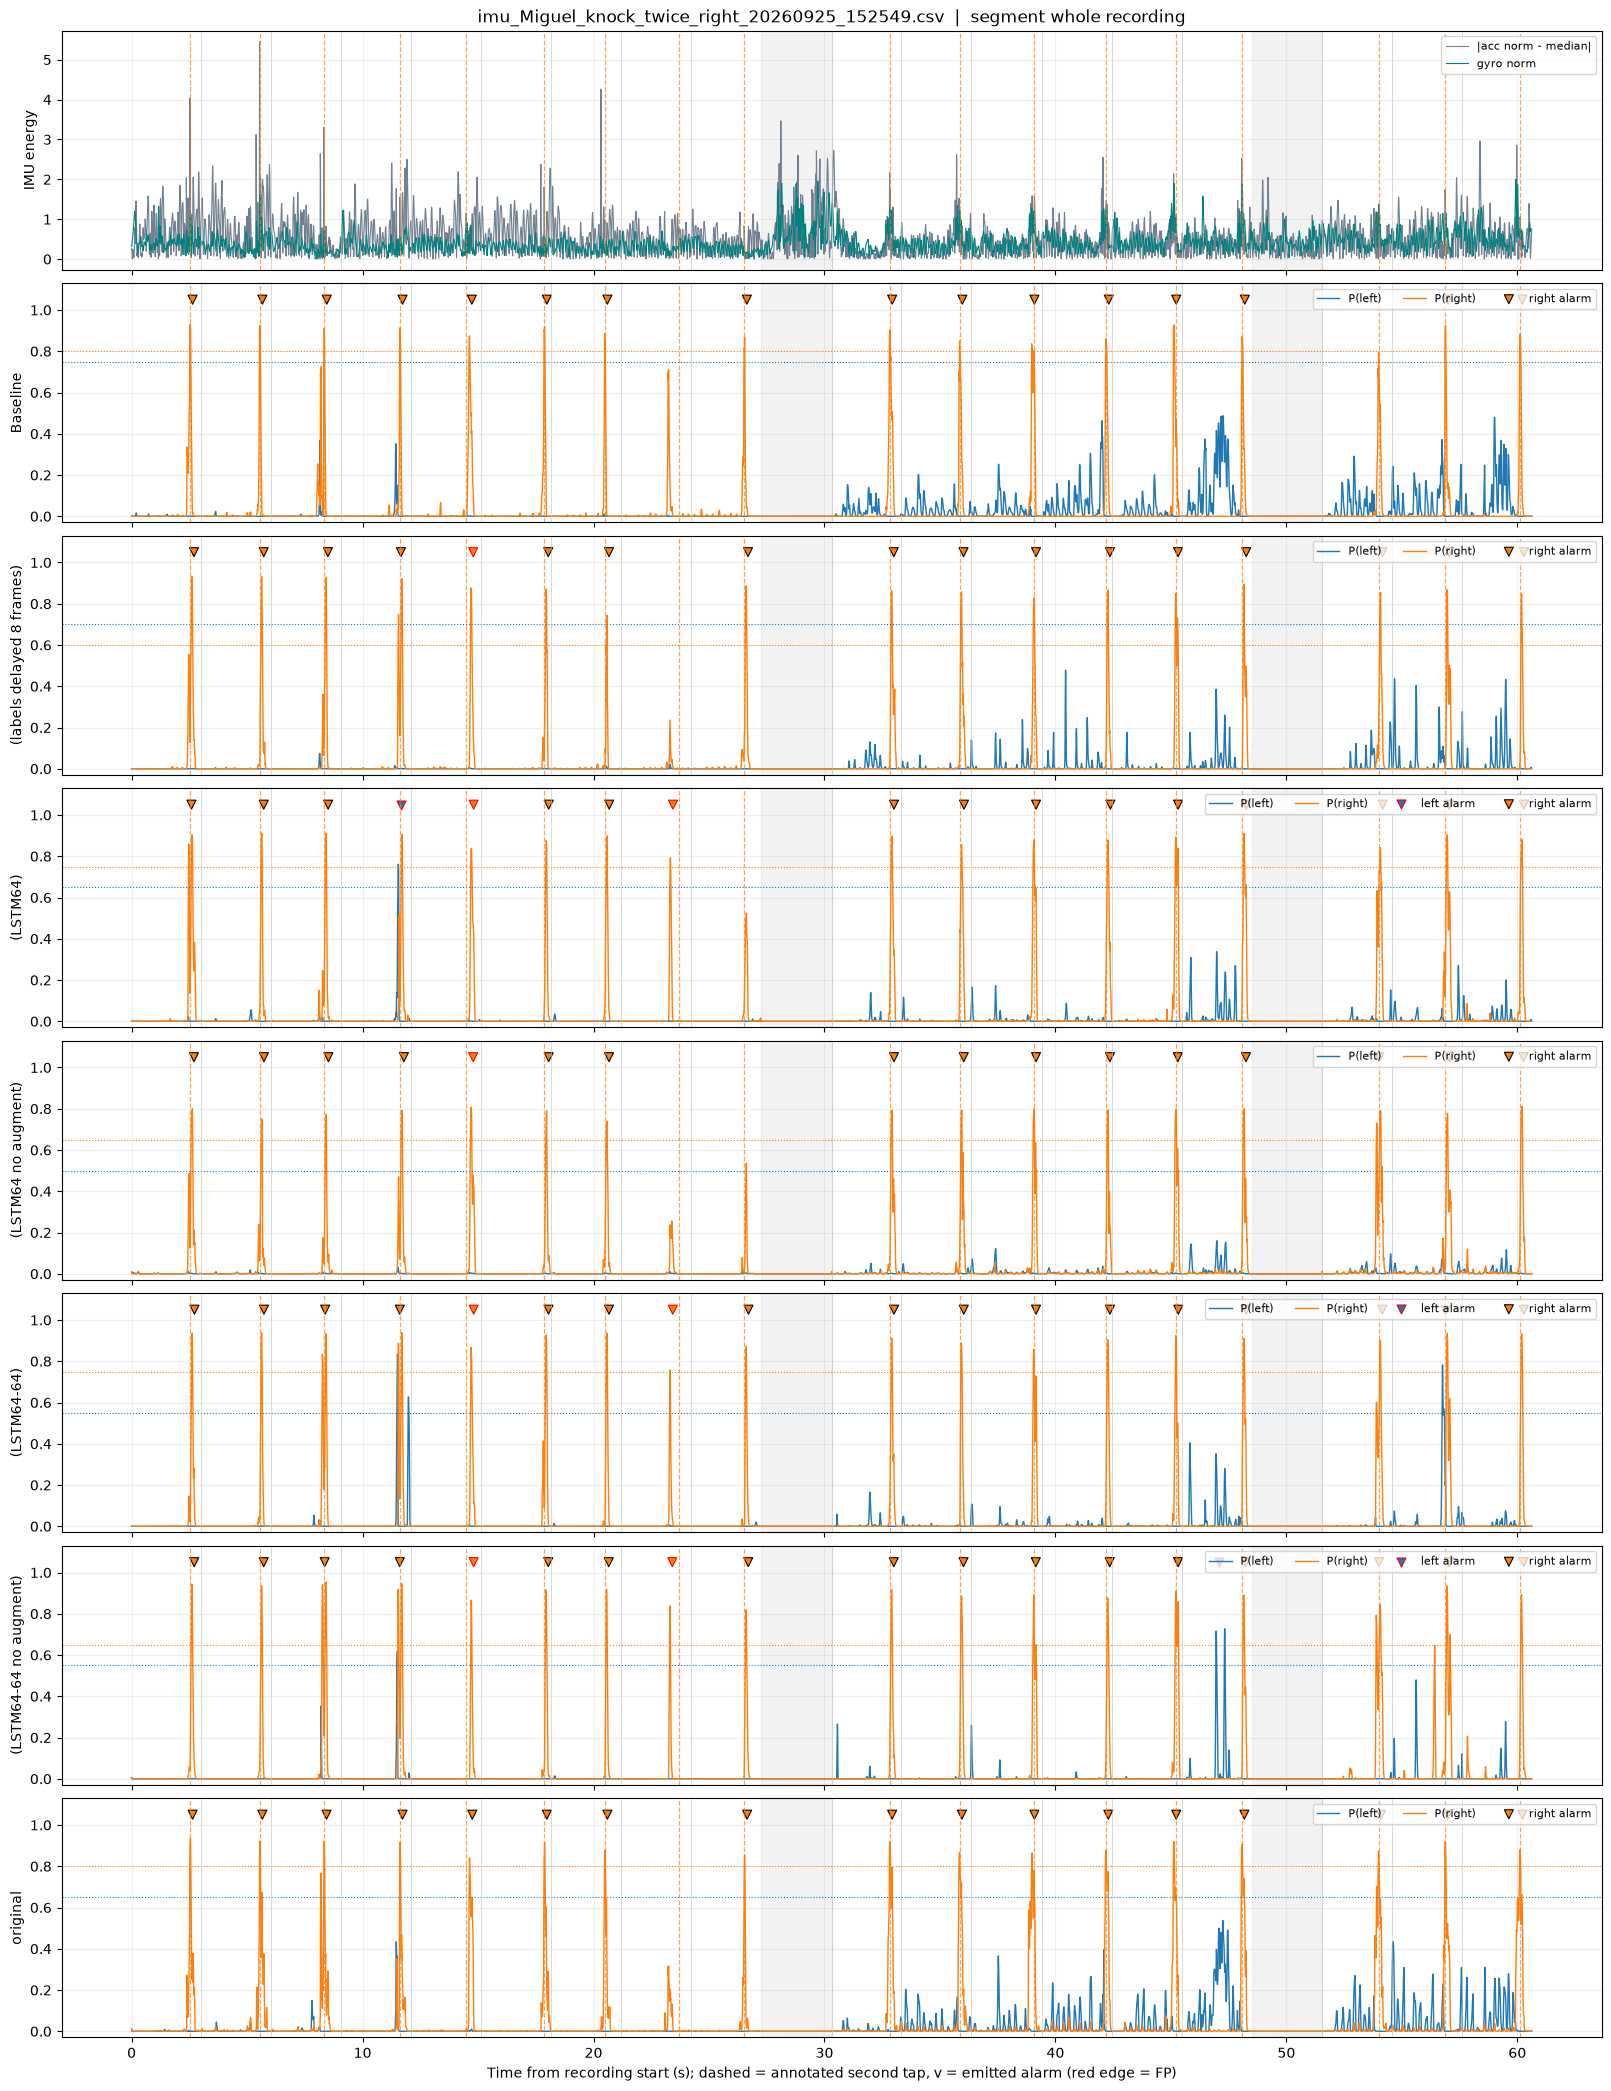

In [26]:
# Replace these values with a file and segment_index from segment_difficulty.
hardest = segment_difficulty.query("recording_type == 'knock_twice'").sort_values(
    ['models_missing', 'too_early_fp', 'models_false_alarm'], ascending=False).iloc[0]
# REVIEW_FILE = hardest['file']
# REVIEW_SEGMENT = int(hardest['segment_index'])  # None = whole recording
REVIEW_FILE = 'imu_Miguel_knock_twice_right_20260925_152549.csv'
REVIEW_SEGMENT = None
display(segment_scores.query('file == @REVIEW_FILE and segment_index == @REVIEW_SEGMENT')
        [['model', 'file', 'segment_index', 'window_true', 'window_pred',
          'event_tp', 'event_fp', 'event_fn', 'too_early_fp', 'latency_frames']])
fig, axes = plot_example(example_recordings, example_traces, alarm_details,
                         detail_points, REVIEW_FILE, REVIEW_SEGMENT)
plt.show()

## Inspect individual training examples (current recordings)
Replay the same selected checkpoints on their **current training files**, using the validation-selected thresholds and alarm policy from `detail_points`. High-pass filtering, window fitting, exclusions, and physical second-tap annotations are handled as in the validation inspection. Inference uses eval mode with no amplitude augmentation; no weights or thresholds are updated.

The `train_*` tables and traces support label review on examples used for fitting the models. Agreement across models, a probability peak away from the annotation, or an unusual rhythm can identify review candidates. Agreement is a clue rather than ground truth: these models share the training labels and can learn the same annotation error. Inspect the raw signal and neighboring segments before deciding whether a physical second-tap label is wrong.

`train_example_data_status` records the current training-data hash; it is not compared with a validation export hash. The replay uses current exclusions, so excluded sessions are absent. Segment IDs come from the CSV's `segment_index`.

In [20]:
train_example_recordings, train_example_traces, train_segment_scores, train_recording_scores, train_alarm_details, train_example_data_status = (
    replay_examples(ROOT, detail_points, split='train')
)
display(train_example_data_status)
print('Training replay:', len(train_segment_scores), 'model/segment rows,',
      len(train_recording_scores), 'model/recording rows,', len(train_alarm_details), 'alarms')

  Excluding session(s) [8] from imuStrict_Miguel_knock_twice_left_20260929_115133.csv
  Excluding session(s) [15] from imu_Miguel_knock_twice_left_20260924_093125.csv
  Excluding session(s) [2, 6, 12, 13, 16, 19] from imu_Miguel_knock_twice_left_20260925_105524.csv
  Excluding session(s) [1, 6, 7, 10, 17, 19] from imu_Miguel_knock_twice_left_20260925_152309.csv
  Excluding session(s) [10, 19] from imu_Miguel_knock_twice_right_20260923_113114.csv
  Excluding session(s) [2, 9] from imu_Miguel_knock_twice_right_20260924_093233.csv
  Excluding session(s) [4, 9, 13, 14, 16, 18, 19, 20] from imu_Miguel_knock_twice_right_20260925_105401.csv
  Excluding session(s) [19] from imu_Miguel_knock_twice_right_20260925_152103.csv
  Excluding session(s) [1] from imu_OLV_knock_twice_left_20260923_174506.csv


,model,split,current_training_sha256
0,Baseline,train,58b9fc95407a6cbf44b1f0f62a939ca134c1f42d6cd45f...
1,(labels delayed 8 frames),train,58b9fc95407a6cbf44b1f0f62a939ca134c1f42d6cd45f...
2,(LSTM64),train,58b9fc95407a6cbf44b1f0f62a939ca134c1f42d6cd45f...
3,(LSTM64 no augment),train,58b9fc95407a6cbf44b1f0f62a939ca134c1f42d6cd45f...
4,(LSTM64-64),train,58b9fc95407a6cbf44b1f0f62a939ca134c1f42d6cd45f...
5,(LSTM64-64 no augment),train,58b9fc95407a6cbf44b1f0f62a939ca134c1f42d6cd45f...
6,original,train,58b9fc95407a6cbf44b1f0f62a939ca134c1f42d6cd45f...


Training replay: 10444 model/segment rows, 532 model/recording rows, 6390 alarms


### Find difficult segments and recordings for training examples
`train_segment_scores`, `train_recording_scores`, and `train_alarm_details` have the same inspection fields as the validation tables. `train_segment_matrix` and `train_recording_matrix` align models side by side. `train_segment_difficulty` adds `n_models` and `models_detecting` to the error counts so you can filter for shared disagreements. For example, use `.query('models_missing == n_models or models_false_alarm == n_models')` to find segments where every model has a missed annotation or an unmatched alarm. These counts do not establish that the models selected the same physical moment; inspect the aligned plots for timing agreement.

Use `train_segment_scores.query("recording_type == 'knock_twice' and event_fn > 0")` for missed taps, or `.query('event_fp > 0')` for unmatched alarms in positive or negative recordings. `train_alarm_details` includes original global peak/emission frames and the closest annotation. Window classification is separate from continuous alarm matching.

In [21]:
train_segment_matrix = comparison_matrix(train_segment_scores, ['file', 'segment_index'],
    ['window_true', 'window_pred', 'window_correct', 'window_fp', 'window_fn',
     'p_left_max', 'p_right_max', 'event_tp', 'event_fp', 'event_fn',
     'too_early_fp', 'wrong_side_fp', 'latency_frames'])
train_recording_matrix = comparison_matrix(train_recording_scores, ['file'],
    ['recording_type', 'minutes', 'n_windows', 'window_accuracy', 'window_fp', 'window_fn',
     'n_true_events', 'event_tp', 'event_fp', 'event_fn', 'too_early_fp',
     'wrong_side_fp', 'event_fp_per_min'])
train_segment_difficulty = train_segment_scores.groupby(
    ['file', 'segment_index', 'recording_type'], as_index=False).agg(
        n_models=('model', 'nunique'), n_true_events=('n_true_events', 'first'),
        models_detecting=('n_alarms', lambda x: (x > 0).sum()),
        models_missing=('event_fn', lambda x: (x > 0).sum()),
        models_false_alarm=('event_fp', lambda x: (x > 0).sum()),
        models_window_wrong=('window_correct', lambda x: (x == False).sum()),
        too_early_fp=('too_early_fp', 'sum'), wrong_side_fp=('wrong_side_fp', 'sum'))
with pd.option_context('display.max_colwidth', None):
    print('Hard training double-tap segments (one row per CSV segment):')
    display(train_segment_difficulty.query("recording_type == 'knock_twice'")
            .sort_values(['models_missing', 'too_early_fp', 'models_false_alarm'],
                         ascending=False).head(25))
    print('Training segments with shared annotation disagreements:')
    display(train_segment_difficulty.query(
        'models_missing == n_models or models_false_alarm == n_models')
        .sort_values(['models_missing', 'models_false_alarm'], ascending=False).head(25))
    print('Hard training recordings (one row per model/recording):')
    display(train_recording_scores.sort_values(['event_fp_per_min', 'event_fn'], ascending=False)
            [['model', 'file', 'recording_type', 'n_true_events', 'event_tp', 'event_fp',
              'event_fn', 'too_early_fp', 'window_fp', 'event_fp_per_min']].head(25))

Hard training double-tap segments (one row per CSV segment):


,file,segment_index,recording_type,n_models,n_true_events,models_detecting,models_missing,models_false_alarm,models_window_wrong,too_early_fp,wrong_side_fp
1393,imu_YYQ_knock_twice_right_20260904_095740.csv,2,knock_twice,7,1,7,7,7,0,7,0
1450,imu_Ym_knock_twice_right_20260904_110925.csv,19,knock_twice,7,1,6,7,6,1,6,0
440,imuStrict_Miguel_knock_twice_right_20260930_152158.csv,2,knock_twice,7,1,5,7,5,2,5,0
1378,imu_YYQ_knock_twice_left_20260904_095856.csv,7,knock_twice,7,1,7,6,6,0,6,0
419,imuStrict_Miguel_knock_twice_right_20260930_152047.csv,1,knock_twice,7,1,4,6,3,3,3,0
1406,imu_YYQ_knock_twice_right_20260904_095740.csv,15,knock_twice,7,1,7,5,5,0,5,0
1394,imu_YYQ_knock_twice_right_20260904_095740.csv,3,knock_twice,7,1,5,5,3,2,3,0
950,imu_Miguel_knock_twice_right_20260925_152103.csv,17,knock_twice,7,1,7,5,7,0,0,0
220,imuStrict_Miguel_knock_twice_left_20260930_151654.csv,2,knock_twice,7,1,2,5,0,5,0,0
225,imuStrict_Miguel_knock_twice_left_20260930_151654.csv,7,knock_twice,7,1,2,5,0,5,0,0


Training segments with shared annotation disagreements:


,file,segment_index,recording_type,n_models,n_true_events,models_detecting,models_missing,models_false_alarm,models_window_wrong,too_early_fp,wrong_side_fp
1393,imu_YYQ_knock_twice_right_20260904_095740.csv,2,knock_twice,7,1,7,7,7,0,7,0
1450,imu_Ym_knock_twice_right_20260904_110925.csv,19,knock_twice,7,1,6,7,6,1,6,0
440,imuStrict_Miguel_knock_twice_right_20260930_152158.csv,2,knock_twice,7,1,5,7,5,2,5,0
950,imu_Miguel_knock_twice_right_20260925_152103.csv,17,knock_twice,7,1,7,5,7,0,0,0
94,imuStrict_Miguel_knock_twice_left_20260929_152105.csv,16,knock_twice,7,1,7,4,7,0,0,0
852,imu_Miguel_knock_twice_right_20260923_113114.csv,7,knock_twice,7,1,7,3,7,0,0,0
875,imu_Miguel_knock_twice_right_20260923_173517.csv,12,knock_twice,7,1,7,3,7,0,0,0
952,imu_Miguel_knock_twice_right_20260925_152103.csv,20,knock_twice,7,1,7,3,7,0,0,0
947,imu_Miguel_knock_twice_right_20260925_152103.csv,14,knock_twice,7,1,7,1,7,0,0,0


Hard training recordings (one row per model/recording):


,model,file,recording_type,n_true_events,event_tp,event_fp,event_fn,too_early_fp,window_fp,event_fp_per_min
453,Baseline,imu_Ym_knock_twice_right_20260904_110925.csv,knock_twice,20,12,8,8,8,0,7.926024
510,original,imu_Miguel_pick_place_20260930_105549.csv,pick_place,0,0,6,0,0,5,5.939614
509,original,imu_Miguel_pick_place_20260930_105321.csv,pick_place,0,0,6,0,0,6,5.938634
51,(LSTM64 no augment),imu_Miguel_pick_place_20260930_104325.csv,pick_place,0,0,5,0,0,5,4.956220
424,Baseline,imu_Miguel_knock_twice_right_20260923_173517.csv,knock_twice,20,15,5,5,3,0,4.950495
31,(LSTM64 no augment),imu_Miguel_knock_once_20260929_141525.csv,knock_once,0,0,5,0,0,5,4.948046
456,original,imuStrict_Miguel_knock_twice_left_20260929_115133.csv,knock_twice,19,12,4,7,4,0,4.168114
127,(LSTM64),imu_Miguel_pick_place_20260930_104325.csv,pick_place,0,0,4,0,0,3,3.964976
451,Baseline,imu_YYQ_knock_twice_right_20260904_095740.csv,knock_twice,20,15,4,5,4,0,3.963666
375,(labels delayed 8 frames),imu_YYQ_knock_twice_right_20260904_095740.csv,knock_twice,20,16,4,4,4,0,3.963666


### Aligned recording/segment inspection on training examples
Choose `TRAIN_REVIEW_FILE` and `TRAIN_REVIEW_SEGMENT` from `train_segment_difficulty`. The default selects a difficult training double-tap segment; set `TRAIN_REVIEW_SEGMENT = None` to inspect the entire recording and compare the rhythm with neighboring sessions. The raw IMU row, annotated physical second taps, model probabilities, thresholds, and emitted alarms share the original recording's time axis. Training-target delay is not added to the annotation markers.

For tabular inspection of all models together, use `train_segment_matrix.loc[('filename.csv', 8)]` or `train_recording_matrix.loc['filename.csv']`. To check an individual alarm, filter `train_alarm_details` by file and segment.

,model,file,segment_index,window_true,window_pred,event_tp,event_fp,event_fn,too_early_fp,latency_frames
439,Baseline,imuStrict_Miguel_knock_twice_right_20260930_15...,1,2,0,0,0,1,0,NaN
440,Baseline,imuStrict_Miguel_knock_twice_right_20260930_15...,2,2,0,0,0,1,0,NaN
441,Baseline,imuStrict_Miguel_knock_twice_right_20260930_15...,3,2,2,1,0,0,0,12.0
442,Baseline,imuStrict_Miguel_knock_twice_right_20260930_15...,4,2,2,1,0,0,0,13.0
443,Baseline,imuStrict_Miguel_knock_twice_right_20260930_15...,5,2,2,1,0,0,0,13.0
...,...,...,...,...,...,...,...,...,...,...
9406,original,imuStrict_Miguel_knock_twice_right_20260930_15...,16,2,0,0,0,1,0,NaN
9407,original,imuStrict_Miguel_knock_twice_right_20260930_15...,17,2,2,1,0,0,0,2.0
9408,original,imuStrict_Miguel_knock_twice_right_20260930_15...,18,2,2,1,0,0,0,13.0
9409,original,imuStrict_Miguel_knock_twice_right_20260930_15...,19,2,0,0,0,1,0,NaN


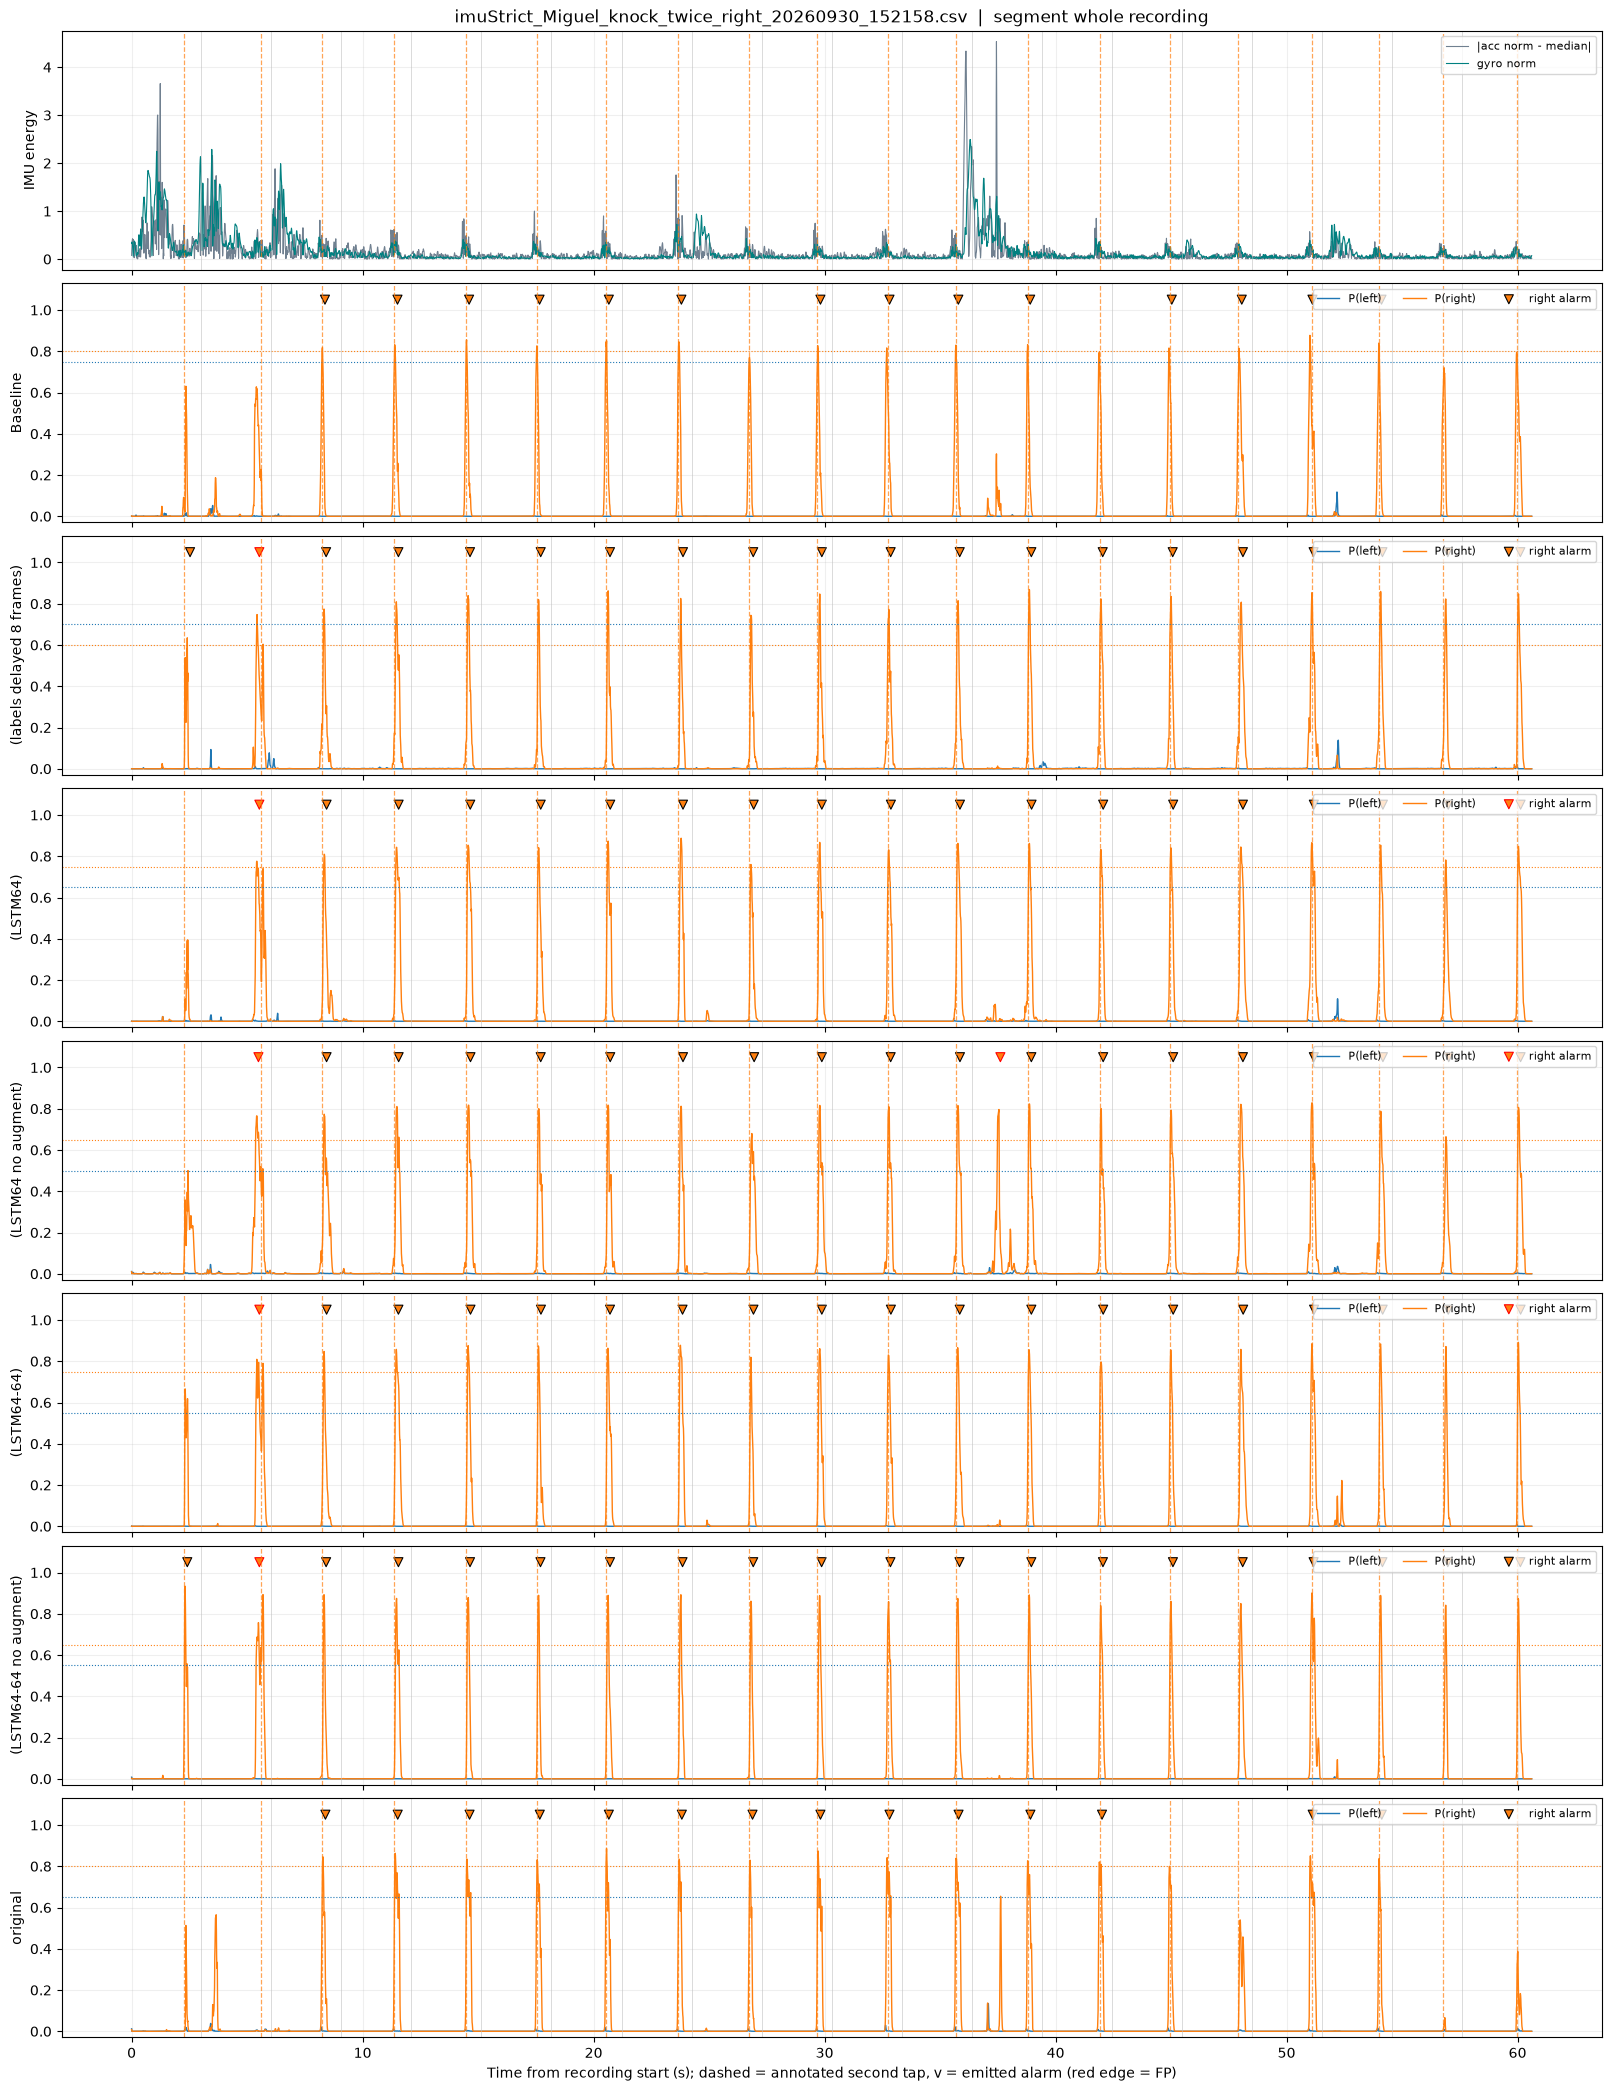

In [22]:
train_review_candidates = train_segment_difficulty.query("recording_type == 'knock_twice'")
if train_review_candidates.empty:
    train_review_candidates = train_segment_difficulty
train_hardest = train_review_candidates.sort_values(
    ['models_missing', 'too_early_fp', 'models_false_alarm'], ascending=False).iloc[0]
# Replace these values with a file and CSV segment_index from the training tables.
TRAIN_REVIEW_FILE = 'imuStrict_Miguel_knock_twice_right_20260930_152158.csv'
TRAIN_REVIEW_SEGMENT = None  # None = whole recording
train_review_rows = train_segment_scores[train_segment_scores.file == TRAIN_REVIEW_FILE]
if TRAIN_REVIEW_SEGMENT is not None:
    train_review_rows = train_review_rows[train_review_rows.segment_index == TRAIN_REVIEW_SEGMENT]
display(train_review_rows[['model', 'file', 'segment_index', 'window_true', 'window_pred',
                         'event_tp', 'event_fp', 'event_fn', 'too_early_fp', 'latency_frames']])
train_fig, train_axes = plot_example(train_example_recordings, train_example_traces, train_alarm_details,
                                    detail_points, TRAIN_REVIEW_FILE, TRAIN_REVIEW_SEGMENT)
plt.show()